In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the clean data we already saved
import warnings
warnings.filterwarnings('ignore')

# Re-run cleaning steps to get df_clean
df = pd.read_csv('../data/data.csv', encoding='ISO-8859-1')
df_clean = df.dropna(subset=['CustomerID'])
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Data ready:", df_clean.shape)

Data ready: (397884, 9)


In [3]:
# Reference date = day after the last transaction in the dataset
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print(rfm.shape)
rfm.head(10)

(4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [4]:
# Step 1 — Scale the RFM values so all 3 columns are comparable
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print("Scaled data shape:", rfm_scaled.shape)
print("First 3 rows scaled:\n", rfm_scaled[:3])

Scaled data shape: (4338, 3)
First 3 rows scaled:
 [[ 2.33457414 -0.4250965   8.35866818]
 [-0.90534032  0.3544168   0.25096626]
 [-0.17535959 -0.03533985 -0.02859601]]


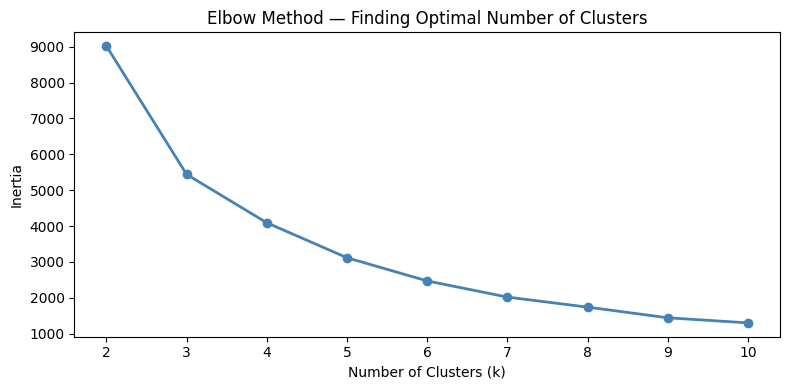

In [5]:
# The Elbow Method — finds the best number of customer segments
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Method — Finding Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [6]:
# Build K-Means with 4 clusters — our chosen number from the elbow
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Customers per cluster:")
print(rfm['Cluster'].value_counts())
rfm.head(10)

Customers per cluster:
Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1
5,12352.0,36,8,2506.04,0
6,12353.0,204,1,89.00,1
7,12354.0,232,1,1079.40,1
8,12355.0,214,1,459.40,1
9,12356.0,23,3,2811.43,0


In [7]:
# Analyze each cluster — what kind of customers are in each group?
cluster_summary = rfm.groupby('Cluster').agg(
    Recency_avg   = ('Recency', 'mean'),
    Frequency_avg = ('Frequency', 'mean'),
    Monetary_avg  = ('Monetary', 'mean'),
    Customer_count= ('CustomerID', 'count')
).round(1)

print(cluster_summary)

         Recency_avg  Frequency_avg  Monetary_avg  Customer_count
Cluster                                                          
0               43.7            3.7        1359.0            3054
1              248.1            1.6         480.6            1067
2                7.4           82.5      127338.3              13
3               15.5           22.3       12709.1             204


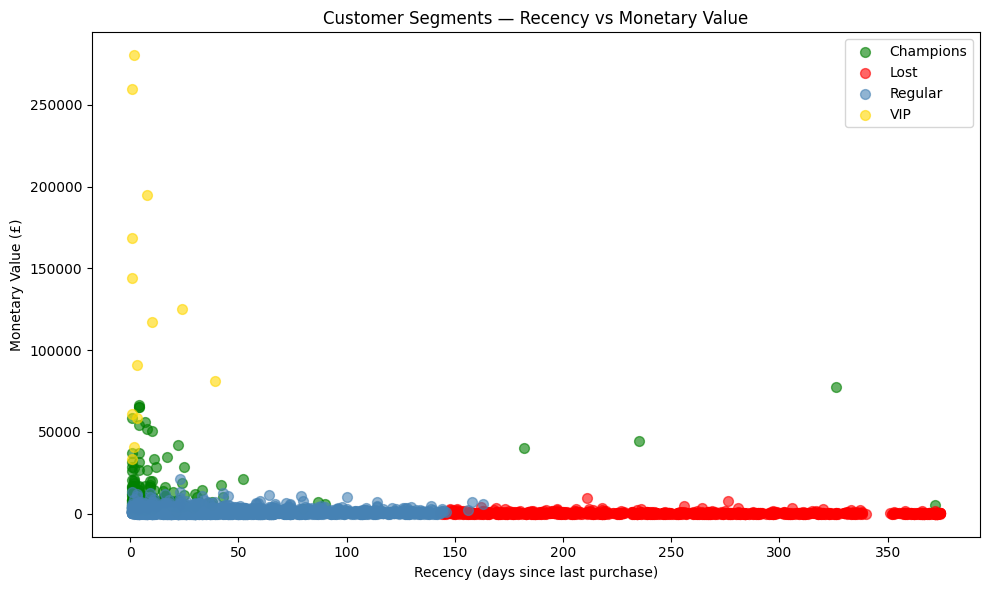

In [8]:
# Name the clusters properly
cluster_names = {0: 'Regular', 1: 'Lost', 2: 'VIP', 3: 'Champions'}
rfm['Segment'] = rfm['Cluster'].map(cluster_names)

# Visualize segments by Recency vs Monetary
plt.figure(figsize=(10, 6))
colors = {'Regular': 'steelblue', 'Lost': 'red', 
          'VIP': 'gold', 'Champions': 'green'}

for segment, group in rfm.groupby('Segment'):
    plt.scatter(group['Recency'], group['Monetary'],
                label=segment, alpha=0.6, 
                color=colors[segment], s=50)

plt.title('Customer Segments — Recency vs Monetary Value')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary Value (£)')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Save the segmented customer data
rfm.to_csv('../data/customer_segments.csv', index=False)
print("Saved! Segments breakdown:")
print(rfm['Segment'].value_counts())

Saved! Segments breakdown:
Segment
Regular      3054
Lost         1067
Champions     204
VIP            13
Name: count, dtype: int64
